In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn

import os, random


def reset_random_seeds():
    os.environ['PYTHONHASHSEED']=str(2)
    torch.manual_seed(2)
    np.random.seed(2)
    random.seed(2)
    torch.cuda.manual_seed(2)
    torch.cuda.manual_seed_all(2)
    
reset_random_seeds()    

df = pd.read_csv("/home/bibek/train.csv")
input_col = "samples"
output_col = "targets"

X = df[input_col].values
Y = df[output_col].values

In [3]:
len(X)

950

In [4]:
from custom_tokenizer import BytePairEncodingTokenizer
import re
import spacy
from tqdm.auto import tqdm


# load tokenizer
tokenizer = BytePairEncodingTokenizer()
tokenizer.load_tokenizer('tokenizer.pkl')


nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "ner", "lemmatizer", "attribute_ruler"])

HEX = re.compile(r'&#x[0-9A-Fa-f]+;')
DEC = re.compile(r'&#\d+;')
ASCII = re.compile(r'[^\x00-\x7F]+')
URL = re.compile(r'http\S+|www\S+')
ESCAPES = re.compile(r'[\n\t\r]+')

def clean_regex_only(text):
    """Only performs the fast regex string replacement."""
    x = str(text).lower()
    x = x.replace("&amp;","&").replace("<br />",'')
    x = HEX.sub('', x)
    x = DEC.sub("'", x)
    x = ASCII.sub("'", x)
    x = ESCAPES.sub(" ",x)
    x = URL.sub('LINK', x) 
    return x.strip()

def preprocess(text,nlp):
    clean_text = clean_regex_only(text)    
    sent = nlp.tokenizer(clean_text)
    sent = ' '.join([tok.text for tok in sent])
    return sent


X = [preprocess(sent,nlp) for sent in tqdm(X)]


  0%|          | 0/950 [00:00<?, ?it/s]

In [5]:
tokenizer.maxlen = 256

X = [tokenizer.tokenize(x) for x in tqdm(X)]
X = np.array([tokenizer.add_padding(x) for x in tqdm(X)],np.int16)

  0%|          | 0/950 [00:00<?, ?it/s]

  0%|          | 0/950 [00:00<?, ?it/s]

In [6]:
for _ in range(10):
    
    i = np.random.randint(0,len(X))
    sample = ' '.join([tokenizer.i2w[t] for t in X[i] if t>0])
    print(sample)
    print()

<cls> --@ ca itly n <unk> jen ner --the --" --deep --state --" --is --just --another --term --for --the --entre n ched --power --structures --that --benefit --from --maintaining --control --. --trump --is --n't --the --obst acle ' he --'s --the --symptom --. --the --real --issue --is --the --system --that --allows --such --power --to --exist --un checked --. --the --" --deep --state --" --is --deep --because --it --'s --not --just --a --group --, --it --'s --a --culture --. <sep>

<cls> --@ sec blin ken --greece --'s --values --are --more --aligned --with --nat o --than --your --policies --. <sep>

<cls> --@ bb <unk> updates --you --are --the --only --one --in --the --house --that --would --want --to --get --rid --of --her --. --if --you --are --serious --about --this --, --you --need --to --put --it --on --the --table --. <sep>

<cls> --@ kim guil fo yl e --@ the dc pun di t --@ cat hy he ss 75 600 31 9 --@ real donald trump --i --agree --with --the --first --part --, --and --the --la

In [7]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.8,random_state=1)

In [9]:
len(xtrain),len(xtest)

(760, 190)

In [6]:
MAXLEN = tokenizer.maxlen
D_MODEL = 256
N_HEADS = 8
N_LAYERS = 4
FF_UNITS = D_MODEL * 3
PEAK_LR = 1e-4
END_LR = 1e-6
INIT_LR = 1e-8
WARMUP_RATE = 0.05
BATCH = 4
EMB_DIM = 128
VOCAB_SIZE = tokenizer.vocab_size

In [7]:
class GeometricPooling(nn.Module):
    
    def __init__(self,temp=1):
        super().__init__()
        self.score = None
        self.temp = temp
    
    def forward(self,x,mask):
        mean_vec = (x * ~mask[:,:,torch.newaxis]).sum(1)
        mean_vec = mean_vec / torch.norm(mean_vec,dim=-1)[:,torch.newaxis]
        mean_vec = mean_vec[:,torch.newaxis,:]
        mean_vec = mean_vec.transpose(1,2)
        score = torch.matmul(x,mean_vec).squeeze(-1)
        score = torch.where(mask,-1e8,score)
        score = torch.softmax(score,dim=-1).unsqueeze(-1)
        return torch.sum(x * score,dim=1)
    
    
class AttentionPool(nn.Module):
    
    def __init__(self,dim=256,temp=1):
        super().__init__()
        self.dim = dim 
        self.score = None
        self.w = nn.Linear(dim,1,bias=False)
        self.temp = temp
        
    def forward(self,x,mask=None):
        attn = self.w(x)
        if mask is not None:
            mask = mask[:,:,torch.newaxis]
            attn = torch.where(mask,attn,-1e8)
        attn = torch.softmax(attn/self.temp,axis=1)
        self.score = attn
        x = x * attn
        return x.sum(1)
    
    
class MaskedAvgPool(nn.Module):
    
    def __init__(self):
        super().__init__()
        
    def forward(self,x,mask=None):
        if mask is not None:
            mask = mask[:,:,torch.newaxis]
            attn = torch.where(mask,-1e8,1)
            attn = torch.softmax(attn,axis=1)
            x = x * attn
            return x.sum(1)
        else:
            return x.sum(1)/len(x)

In [8]:
class FactorizeEmbeddingLayer(nn.Module):

    def __init__(self,vocab_size,d_model,maxlen):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.maxlen = maxlen

        self.emb = nn.Embedding(self.vocab_size,self.d_model // 2)
        self.fact_layer = nn.Linear(self.d_model // 2, self.d_model)
        self.pos_encoding = nn.Parameter(self._positional_encoding(),requires_grad=False)

    def _positional_encoding(self):
        pos = np.zeros((self.maxlen, self.d_model), dtype=np.float32)
        for p in range(self.maxlen):
            for i in range(self.d_model):
                exponent = 2 * (i // 2) / self.d_model
                angle = p / (10000 ** exponent)

                if i % 2 == 0:
                    pos[p, i] = np.sin(angle)
                else:
                    pos[p, i] = np.cos(angle)
        return torch.tensor(pos,dtype=torch.float32)

    def forward(self,x):
        mask = x == 0
        x = self.fact_layer(self.emb(x)) + self.pos_encoding[:x.shape[1], :].unsqueeze(0) 
        return x,mask

In [9]:
from encoder_decoder import EncoderLayer
from torchinfo import summary


class Classifier(nn.Module):

    def __init__(self,d_model,vocab_size,maxlen,n_heads,ff_units,n_layers,pool_type='avg_pool',n_classes=1):
        super().__init__()
        
        self.n_layers = n_layers
        self.pool_type = pool_type
        
        self.emb = FactorizeEmbeddingLayer(vocab_size,d_model,maxlen)
        self.encoder = EncoderLayer(d_model,n_heads,ff_units)
        self.pooling = nn.ModuleDict({"avg_pool":MaskedAvgPool(),
                                      "attn_pool":AttentionPool(d_model),
                                      "geometric_pool":GeometricPooling()})
        self.out = nn.Linear(d_model,n_classes)
        

    def forward(self,i,return_pool=False):

        x,mask = self.emb(i)

        for _ in range(self.n_layers):
            x = self.encoder([x,mask])

        x = self.pooling[self.pool_type](x,mask=mask)
        
        if return_pool:
            return x
        
        x = self.out(x)

        return x


reset_random_seeds()

n_classes = len(np.unique(ytrain))

device = torch.device("cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS)

model = model.to(device)

inp = torch.randint(0,VOCAB_SIZE,(BATCH,MAXLEN))
print(summary(model,input_data=inp))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)




Layer (type:depth-idx)                   Output Shape              Param #
Classifier                               [4, 1]                    --
├─FactorizeEmbeddingLayer: 1-1           [4, 256, 256]             65,536
│    └─Embedding: 2-1                    [4, 256, 128]             2,565,248
│    └─Linear: 2-2                       [4, 256, 256]             33,024
├─EncoderLayer: 1-2                      [4, 256, 256]             --
│    └─MultiHeadAttention: 2-3           [4, 256, 256]             --
│    │    └─Linear: 3-1                  [4, 256, 256]             65,536
│    │    └─Linear: 3-2                  [4, 256, 256]             65,536
│    │    └─Linear: 3-3                  [4, 256, 256]             65,536
│    │    └─Dropout: 3-4                 [4, 8, 256, 256]          --
│    │    └─Linear: 3-5                  [4, 256, 256]             65,792
│    │    └─Dropout: 3-6                 [4, 256, 256]             --
│    └─LayerNorm: 2-4                    [4, 256, 256]

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics_dict(y_true, y_pred):
    
    is_standard_binary = len(set(y_true)) <= 2 and set(y_true).issubset({0, 1})
    avg = 'binary' if is_standard_binary else 'weighted'
    
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        "recall": recall_score(y_true, y_pred, average=avg, zero_division=0),
        "f1": f1_score(y_true, y_pred, average=avg, zero_division=0)
    }

metrics = {"avg_pool":None,"attn_pool":None,'geometric_pool':None}



In [11]:
from torch.utils.data import TensorDataset, DataLoader
import torch_optimizer

def create_tensor_data(x,y,batch,shuffle=True):
    
    x_ = torch.tensor(x,dtype=torch.int32,device=device)
    y_ = torch.tensor(y,dtype=torch.int32,device=device)
    data = TensorDataset(x_,y_)
    data = DataLoader(data,batch_size=batch,shuffle=shuffle)
    return data

train = create_tensor_data(xtrain,ytrain,BATCH)
test = create_tensor_data(xtest,ytest,BATCH * 2,shuffle=False)

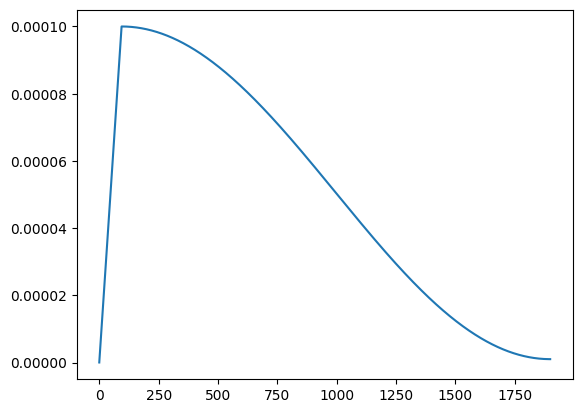

In [12]:
from cosine_lr_scheduler import CosineLRScheduler
import matplotlib.pyplot as plt

EPOCHS = 10
train_steps = len(train) * EPOCHS

lr_scheduler = CosineLRScheduler(train_steps,peak_lr=PEAK_LR,min_lr=END_LR,
                                 init_lr=INIT_LR,warmup_rate=WARMUP_RATE)

plt.plot([lr_scheduler(i) for i in range(1,train_steps+1)])

In [13]:
from tqdm.auto import tqdm


def train_model(data,model,EPOCHS=10,file='saved_weights.pt'):
    
    opt = torch.optim.AdamW(model.parameters(),weight_decay=0.01)
    loss_fn = nn.CrossEntropyLoss()

    train,test = data

    losses = {'train':[],'valid':[]}
    step = 1

    for e in range(1,EPOCHS + 1):

        print(f"{e}/{EPOCHS}")

        loss = 0
        model.train()

        for i,batch in enumerate(tqdm(train),1):

            lr = lr_scheduler(step)
            opt.param_groups[0]['lr'] = lr

            opt.zero_grad()

            x,y = batch
            y = y.long()
            pred = model(x)
            batch_loss = loss_fn(pred,y)
            batch_loss.backward()
            opt.step()

            loss += batch_loss.item()
            step += 1

        loss = round(loss / len(train),4)
        losses['train'].append(loss)

        print(f'Train Loss = {loss}')

        model.eval()
        loss = 0

        with torch.no_grad():

            for i,batch in enumerate(test):

                x,y = batch
                y = y.long()
                pred = model(x)
                batch_loss = loss_fn(pred,y)
                loss += batch_loss.item()

        loss = round(loss / len(test),4)
        print(f"Val Loss = {loss}")


        if e == 1 or loss < min(losses['valid']):
            torch.save(model.state_dict(),file)
            print("--weights saved")

        losses['valid'].append(loss)
        print('-------------------------------------')
        print()

In [14]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,n_classes=n_classes,pool_type='avg_pool')
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='avg_pool.pt')

state_dict = torch.load('avg_pool.pt', map_location=device)
model.load_state_dict(state_dict)

1/10


  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 1.0439
Val Loss = 0.9405
--weights saved
-------------------------------------

2/10


  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 0.9004
Val Loss = 0.8616
--weights saved
-------------------------------------

3/10


...

  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 0.4182
Val Loss = 0.8045
-------------------------------------

10/10


  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 0.395
Val Loss = 0.8059
-------------------------------------



<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.55      0.43      0.48        70
           1       0.53      0.57      0.55        68
           2       0.70      0.83      0.76        52

    accuracy                           0.59       190
   macro avg       0.59      0.61      0.60       190
weighted avg       0.58      0.59      0.58       190

0.5967859071835141


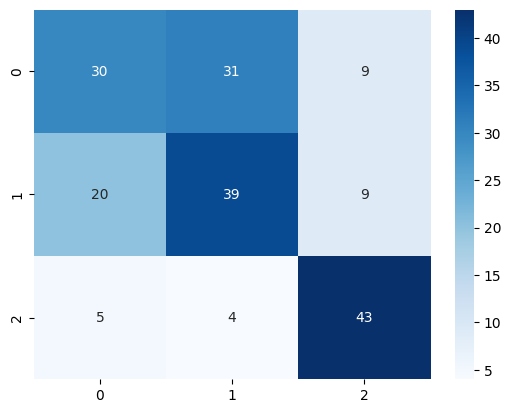

In [15]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x,_ in test:
    pred = model(x)
    pred = torch.softmax(pred,-1)
    pred = torch.argmax(pred,1).cpu().numpy()
    preds.extend(pred)
    
print(classification_report(ytest,preds))
print(f1_score(ytest,preds,average='macro'))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues',annot=True,fmt='d') 

metrics['avg_pool'] = get_metrics_dict(ytest,preds)


In [16]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,
                   n_classes=n_classes,pool_type='attn_pool')
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='attn_pool.pt')

state_dict = torch.load('attn_pool.pt', map_location=device)
model.load_state_dict(state_dict)

1/10


  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 1.062
Val Loss = 0.9724
--weights saved
-------------------------------------

2/10


  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 0.9231
Val Loss = 0.9032
--weights saved
-------------------------------------

3/10


...

  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 0.2841
Val Loss = 0.8994
-------------------------------------

10/10


  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 0.2602
Val Loss = 0.9038
-------------------------------------



<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.53      0.44      0.48        70
           1       0.52      0.54      0.53        68
           2       0.70      0.83      0.76        52

    accuracy                           0.58       190
   macro avg       0.59      0.60      0.59       190
weighted avg       0.58      0.58      0.58       190

0.5926036825406932


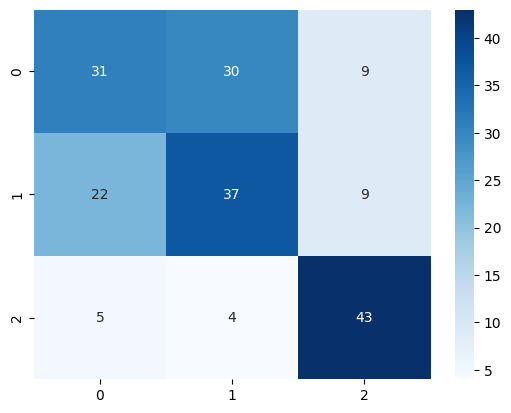

In [17]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x,_ in test:
    pred = model(x)
    pred = torch.softmax(pred,-1)
    pred = torch.argmax(pred,1).cpu().numpy()
    preds.extend(pred)
    
print(classification_report(ytest,preds))
print(f1_score(ytest,preds,average='macro'))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues',annot=True,fmt='d') 

metrics['attn_pool'] = get_metrics_dict(ytest,preds)


In [18]:
reset_random_seeds()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,
                   n_classes=n_classes,pool_type='geometric_pool')
model = model.to(device) 

train_model((train,test),model,EPOCHS=EPOCHS,file='geometric_pool.pt')

state_dict = torch.load('geometric_pool.pt', map_location=device)
model.load_state_dict(state_dict)

1/10


  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 1.0452
Val Loss = 0.9413
--weights saved
-------------------------------------

2/10


  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 0.8966
Val Loss = 0.8899
--weights saved
-------------------------------------

3/10


...

  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 0.1824
Val Loss = 0.9596
-------------------------------------

10/10


  0%|          | 0/190 [00:00<?, ?it/s]

Train Loss = 0.1612
Val Loss = 0.9645
-------------------------------------



<All keys matched successfully>

              precision    recall  f1-score   support

           0       0.55      0.69      0.61        70
           1       0.62      0.43      0.50        68
           2       0.75      0.79      0.77        52

    accuracy                           0.62       190
   macro avg       0.64      0.63      0.63       190
weighted avg       0.63      0.62      0.61       190

0.6260993009942443


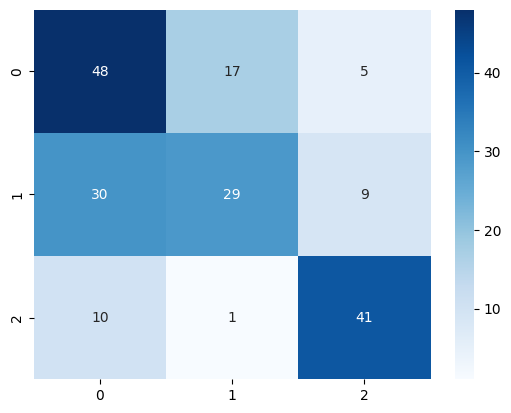

In [19]:
from sklearn.metrics import classification_report,f1_score,confusion_matrix
import seaborn as sb

preds = []

for x,_ in test:
    pred = model(x)
    pred = torch.softmax(pred,-1)
    pred = torch.argmax(pred,1).cpu().numpy()
    preds.extend(pred)
    
print(classification_report(ytest,preds))
print(f1_score(ytest,preds,average='macro'))  

sb.heatmap(confusion_matrix(ytest,preds),cmap='Blues',annot=True,fmt='d') 

metrics['geometric_pool'] = get_metrics_dict(ytest,preds)


In [20]:
import json


with open("custom_tweet_metrics_.json",'w') as f:
    json.dump(metrics,f)

In [21]:
metrics

{'avg_pool': {'accuracy': 0.5894736842105263,
  'precision': 0.5825020722346002,
  'recall': 0.5894736842105263,
  'f1': 0.5817228100789178},
 'attn_pool': {'accuracy': 0.5842105263157895,
  'precision': 0.5763481606667166,
  'recall': 0.5842105263157895,
  'f1': 0.5772784741466259},
 'geometric_pool': {'accuracy': 0.6210526315789474,
  'precision': 0.6258047439682378,
  'recall': 0.6210526315789474,
  'f1': 0.6140935001750153}}

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


def load_model(pool_type):
    model = Classifier(D_MODEL,VOCAB_SIZE,MAXLEN,N_HEADS,FF_UNITS,N_LAYERS,
                       n_classes=n_classes,pool_type=pool_type)

    model = model.to('cuda')
    state_dict = torch.load(f'{pool_type}.pt', map_location='cuda')
    model.load_state_dict(state_dict)
    return model

model0 = load_model('avg_pool')
model1 = load_model('attn_pool')
model2 = load_model('geometric_pool')

def get_pooled_vectors(model,test):
    
    with torch.no_grad():

        vectors = []

        for x,_ in test:
            x = x.to('cuda')
            pool_vec = model(x,return_pool=True)
            pool_vec = pool_vec.cpu().numpy()
            vectors.extend(pool_vec)
        
        vectors = np.array(vectors,dtype=np.float32)
        
        return vectors

reset_random_seeds()    
    
vectors0 = get_pooled_vectors(model0,test)
vectors1 = get_pooled_vectors(model1,test)
vectors2 = get_pooled_vectors(model2,test)


def cluster_eval(embeddings,true_labels,name='',classes=len(set(ytrain))):
    kmeans = KMeans(n_clusters=classes, n_init=10, random_state=42)
    cluster_preds = kmeans.fit_predict(embeddings)
    ari = adjusted_rand_score(true_labels, cluster_preds)
    print(f"Clustering ARI against True Sentiment: {ari:.4f} ({name})")
    return ari,name

cluster_eval_metrics = {}

ari,name = cluster_eval(vectors0,ytest,'avg_pool')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors1,ytest,'attn_pool')
cluster_eval_metrics[name] = ari

ari,name = cluster_eval(vectors2,ytest,'geometric_pool')
cluster_eval_metrics[name] = ari

with open("custom_tweet_cluster_metrics_.json",'w') as f:
    json.dump(cluster_eval_metrics,f)

Clustering ARI against True Sentiment: 0.2480 (avg_pool)
Clustering ARI against True Sentiment: 0.1911 (attn_pool)
Clustering ARI against True Sentiment: 0.1804 (geometric_pool)
